In [60]:
import torch
import torchvision
import torch.optim as optim
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)

In [61]:
# Factorize using Gradient Descent
def factorize_gd(img_tensor, k=100, epochs=5000, lr=0.01, epsilon = 0.001):
    # img_tensor: shape (3, n, m)
    C, n, m = img_tensor.shape
    W_matrices = []
    H_matrices = []
    A_fac = []
    losses = []

    for c in range(C):
        A = img_tensor[c]  # shape (n, m)

        mask = ~torch.isnan(A)

        W = torch.rand(n, k, requires_grad=True)
        H = torch.rand(k, m, requires_grad=True)
        optimizer = optim.Adam([W, H], lr)

        prev_loss = float('inf')
        for _ in range(epochs):
            diff_matrix = W @ H - A
            diff_vector = diff_matrix[mask]
            loss = torch.norm(diff_vector)
            
            # Check convergence
            if abs(prev_loss - loss.item())/prev_loss < epsilon:
                print(f"Channel {c}: Converged in {_ + 1} epochs.")
                break
            prev_loss = loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # with torch.no_grad(): # Clip the values in between 0 and 1
            #     W.clamp_(min=0, max=1)
            #     H.clamp_(min=0, max=1)

        W_matrices.append(W.detach())
        H_matrices.append(H.detach())
        A_fac.append(W@H)
        losses.append(loss.item())
    
    # Stack results into tensors
    A_fac = torch.stack(A_fac, dim=0)         # shape: (3, n, m)
    W_matrices = torch.stack(W_matrices, dim=0)        # shape: (3, n, k)
    H_matrices = torch.stack(H_matrices, dim=0)        # shape: (3, k, m)

    return A_fac, W_matrices, H_matrices, losses

def calculate_psnr(true_values, pred_values, max_pixel_value=1.0):
    """Calculates the Peak Signal-to-Noise Ratio."""
    mse = torch.mean((true_values - pred_values) ** 2)
    if mse == 0:
        # PSNR is infinite if the images are identical
        return float('inf')
    psnr = 20 * math.log10(max_pixel_value / math.sqrt(mse.item()))
    return psnr

### a) Image Reconstruction- Here, ground truth pixel values are missing for particular regions within the image- you don't have access to them.
1. [2 Marks] Use an image and reconstruct the image in the following two cases, where your region is-
    * A) a rectangular block of 30X30 is assumed missing from the image.

Original Image


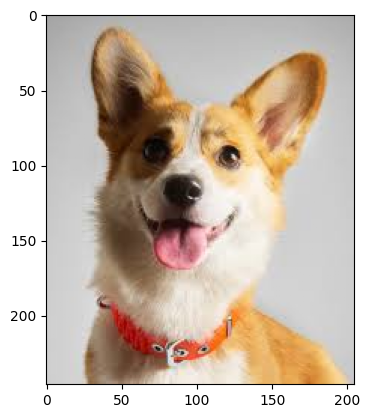

Image with 30*30 block as 0


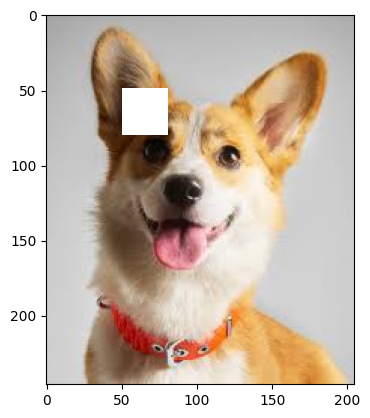

Channel 0: Converged in 844 epochs.
Channel 1: Converged in 800 epochs.
Channel 2: Converged in 788 epochs.
Recovered Image


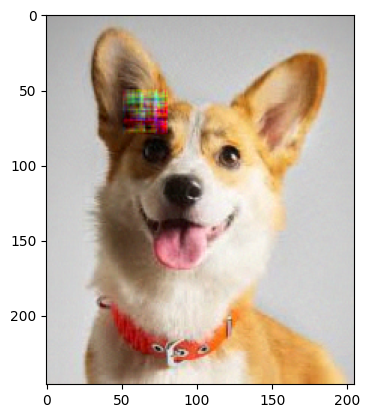

RMSE Loss - 0.030757538974285126
Peak SNR - 30.24 dB


In [62]:
torch.manual_seed(42)
img = torchvision.io.read_image("dog.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Show original Image
imgCopy = img.permute(1, 2, 0)  # change to (n, m, 3)
print("Original Image")
plt.imshow(imgCopy.numpy())
plt.show()

# Show original image with a block as nan
img_with_nan = img.clone()
_, H, W = img_with_nan.shape
block_size = 30
top = torch.randint(0, H - block_size + 1, (1,)).item()
left = torch.randint(0, W - block_size + 1, (1,)).item()
img_with_nan[:, top:top+block_size, left:left+block_size] = float('nan')
imgCopy = img_with_nan.permute(1, 2, 0)  # change to (n, m, 3)
print("Image with 30*30 block as 0") # Missing
plt.imshow(imgCopy.numpy())
plt.show()

# After factorization
A, W, H, losses = factorize_gd(img_with_nan)
A.clamp_(min=0, max=1)
imgCopy = A.permute(1, 2, 0)  # change to (n, m, 3)
print("Recovered Image")
plt.imshow(imgCopy.detach().numpy())
plt.show()

RMSE = torch.sqrt(torch.mean((A - img)**2))
print(f"RMSE Loss - {RMSE}")
print(f"Peak SNR - {calculate_psnr(img, A):.2f} dB")

1. [2 Marks] Use an image and reconstruct the image in the following two cases, where your region is-
    * B) a random subset of 900 (30X30) pixels is missing from the image.

Original Image


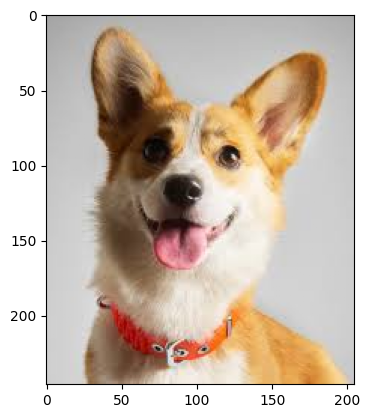

Image with 30*30 block as missing or NaN


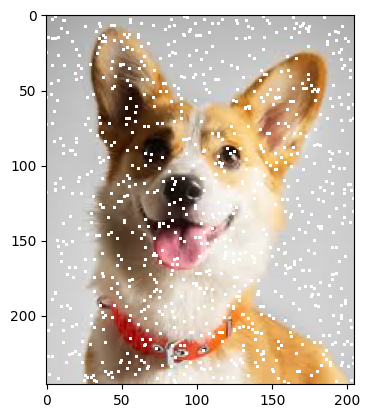

Channel 0: Converged in 745 epochs.
Channel 1: Converged in 848 epochs.
Channel 2: Converged in 835 epochs.
Recovered Image


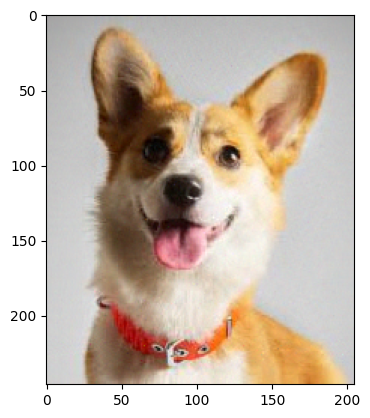

RMSE Loss - 0.012669723480939865
Peak SNR - 37.94 dB


In [63]:
torch.manual_seed(42)
img = torchvision.io.read_image("dog.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Show original Image
imgCopy = img.permute(1, 2, 0)  # change to (n, m, 3)
print("Original Image")
plt.imshow(imgCopy.numpy())
plt.show()

# Show original image with a block as nan
img_with_nan = img.clone()
_, H, W = img_with_nan.shape
num_nan_pixels = 30*30  # total number of pixels to set as NaN
flat_indices = torch.randperm(H * W)[:num_nan_pixels]
rows = flat_indices // W
cols = flat_indices % W
for r, c in zip(rows, cols): img_with_nan[:, r, c] = float('nan')
imgCopy = img_with_nan.permute(1, 2, 0)  # change to (n, m, 3)
print("Image with 30*30 block as missing or NaN") # Missing
plt.imshow(imgCopy.numpy())
plt.show()

# After factorization
A, W, H, losses = factorize_gd(img_with_nan)
A.clamp_(min=0, max=1)
imgCopy = A.permute(1, 2, 0)  # change to (n, m, 3)
print("Recovered Image")
plt.imshow(imgCopy.detach().numpy())
plt.show()

RMSE = torch.sqrt(torch.mean((A - img)**2))
print(f"RMSE Loss - {RMSE}")
print(f"Peak SNR - {calculate_psnr(img, A):.2f} dB")

### [2 Marks] Write a function using this reference and use alternating least squares instead of gradient descent to repeat Part 1, 2 of Image reconstruction problem using your written function.

In [64]:
# Factorize using Alternating Least Squares
def factorize_als(img_tensor, k = 100, max_epochs=50, epsilon = 0.001):
    # img_tensor: shape (3, n, m)
    C, n, m = img_tensor.shape
    W_matrices = []
    H_matrices = []
    A_fac = []
    losses = []

    for c in range(C):
        A = img_tensor[c]  # shape (n, m)
        W = torch.rand(n, k)
        H = torch.rand(k, m)
        mask = ~torch.isnan(A)

        prev_loss = float('inf')
        for _ in range(max_epochs):
            # A = WH, solve for W, keeping H fixed
            for i in range(n):
                row_mask = mask[i, :]
                if not row_mask.any(): continue # No value filled in the row

                A_filt = A[i, row_mask]
                H_filt = H[:, row_mask]
                W[i, :] = torch.linalg.lstsq(H_filt.T, A_filt.T).solution.squeeze()

            # A = WH, solve for H, keeping W fixed
            for j in range(m):
                col_mask = mask[:, j]
                if not col_mask.any(): continue # No value filled in the column

                A_filt = A[col_mask, j]
                W_filt = W[col_mask, :]
                H[:, j] = torch.linalg.lstsq(W_filt, A_filt).solution

            loss = torch.norm((W@H - A)[mask])
            if abs(loss.item() - prev_loss)/prev_loss < epsilon:
                print(f"Channel {c}: Converged in {_ + 1} epochs.")
                break
            prev_loss = loss.item()

        W_matrices.append(W)
        H_matrices.append(H)
        A_fac.append(W@H)
        losses.append(loss.item())
    
    # Stack results into tensors
    A_fac = torch.stack(A_fac, dim=0)         # shape: (3, n, m)
    W_matrices = torch.stack(W_matrices, dim=0)        # shape: (3, n, k)
    H_matrices = torch.stack(H_matrices, dim=0)        # shape: (3, k, m)

    return A_fac, W_matrices, H_matrices, losses

Original Image


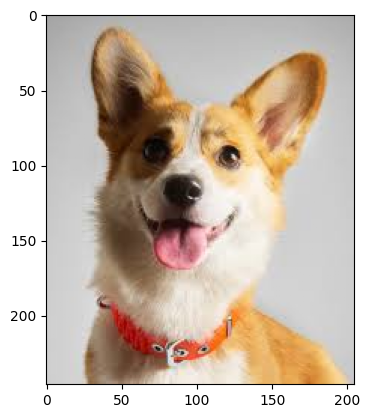

Image with 30*30 block as 0


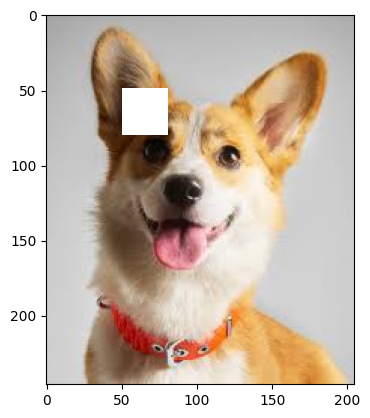

Channel 0: Converged in 25 epochs.
Channel 1: Converged in 28 epochs.
Channel 2: Converged in 26 epochs.
Recovered Image


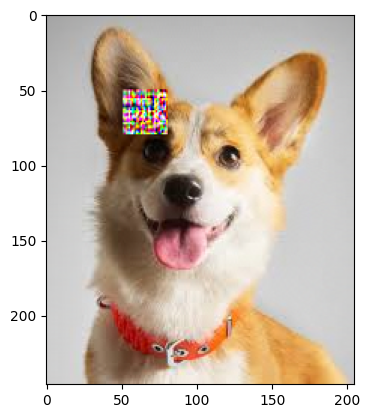

RMSE Loss - 0.066640704870224
Peak SNR - 23.53 dB


In [65]:
torch.manual_seed(42)
img = torchvision.io.read_image("dog.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Show original Image
imgCopy = img.permute(1, 2, 0)  # change to (n, m, 3)
print("Original Image")
plt.imshow(imgCopy.numpy())
plt.show()

# Show original image with a block as nan
img_with_nan = img.clone()
_, H, W = img_with_nan.shape
block_size = 30
top = torch.randint(0, H - block_size + 1, (1,)).item()
left = torch.randint(0, W - block_size + 1, (1,)).item()
img_with_nan[:, top:top+block_size, left:left+block_size] = float('nan')
imgCopy = img_with_nan.permute(1, 2, 0)  # change to (n, m, 3)
print("Image with 30*30 block as 0") # Missing
plt.imshow(imgCopy.numpy())
plt.show()

# After factorization
A, W, H, losses = factorize_als(img_with_nan)
A.clamp_(min=0, max=1)
imgCopy = A.permute(1, 2, 0)  # change to (n, m, 3)
print("Recovered Image")
plt.imshow(imgCopy.numpy())
plt.show()

RMSE = torch.sqrt(torch.mean((A - img)**2))
print(f"RMSE Loss - {RMSE}")
print(f"Peak SNR - {calculate_psnr(img, A):.2f} dB")

Original Image


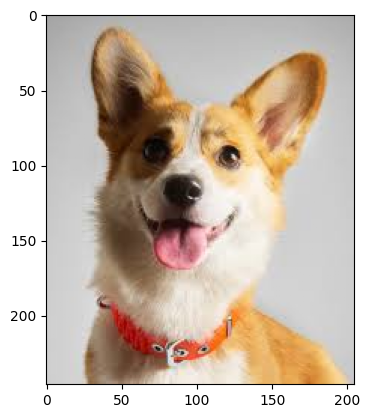

Image with 30*30 block as 0


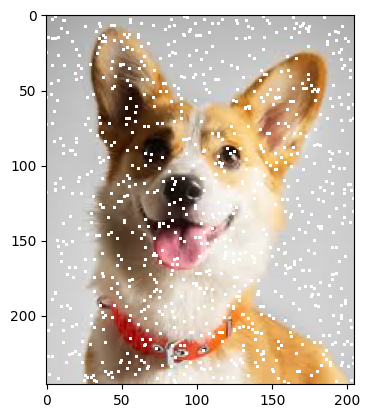

Channel 0: Converged in 29 epochs.
Channel 1: Converged in 25 epochs.
Channel 2: Converged in 22 epochs.
Recovered Image


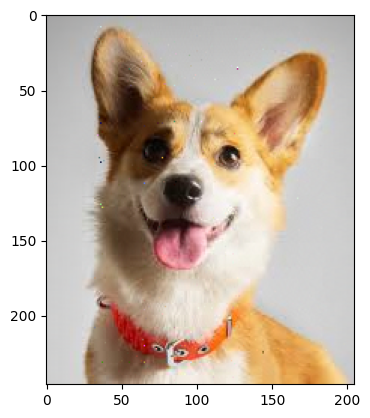

RMSE Loss - 0.009962312877178192
Peak SNR - 40.03 dB


In [66]:
torch.manual_seed(42)
img = torchvision.io.read_image("dog.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Show original Image
imgCopy = img.permute(1, 2, 0)  # change to (n, m, 3)
print("Original Image")
plt.imshow(imgCopy.numpy())
plt.show()

# Show original image with a block as nan
img_with_nan = img.clone()
_, H, W = img_with_nan.shape
num_nan_pixels = 30*30  # total number of pixels to set as NaN
flat_indices = torch.randperm(H * W)[:num_nan_pixels]
rows = flat_indices // W
cols = flat_indices % W
for r, c in zip(rows, cols): img_with_nan[:, r, c] = float('nan')
imgCopy = img_with_nan.permute(1, 2, 0)  # change to (n, m, 3)
print("Image with 30*30 block as 0") # Missing
plt.imshow(imgCopy.numpy())
plt.show()

# After factorization
A, W, H, losses = factorize_als(img_with_nan)
A.clamp_(min=0, max=1)
imgCopy = A.permute(1, 2, 0)  # change to (n, m, 3)
print("Recovered Image")
plt.imshow(imgCopy.numpy())
plt.show()

RMSE = torch.sqrt(torch.mean((A - img)**2))
print(f"RMSE Loss - {RMSE}")
print(f"Peak SNR - {calculate_psnr(img, A):.2f} dB")

### b) Data Compression- Here, ground truth pixel values are not missing- you have access to them. You want to explore the use of matrix factorisation in order to store them more efficiently.

In [153]:
# Factorize using Gradient Descent
def factorize_gd(img_tensor, k, epochs=5000, lr=0.01, epsilon = 0.001):
    # img_tensor: shape (3, n, m)
    C, n, m = img_tensor.shape
    W_matrices = []
    H_matrices = []
    
    for c in range(C):
        A = img_tensor[c]  # shape (n, m)
        W = torch.rand(n, k, requires_grad=True)
        H = torch.rand(k, m, requires_grad=True)
        optimizer = optim.Adam([W, H], lr)

        prev_loss = float('inf')
        for _ in range(epochs):
            loss = torch.norm(W @ H - A)
            
            # Check convergence
            if abs(prev_loss - loss.item())/prev_loss < epsilon:
                print(f"Channel {c}: Converged in {_ + 1} epochs.")
                break
            prev_loss = loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        W_matrices.append(W.detach())
        H_matrices.append(H.detach())
    
    # Stack results into tensors
    W_matrices = torch.stack(W_matrices, dim=0)        # shape: (3, n, k)
    H_matrices = torch.stack(H_matrices, dim=0)        # shape: (3, k, m)

    return W_matrices, H_matrices

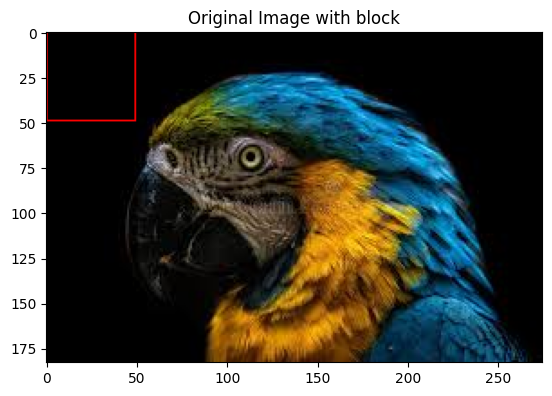

Channel 0: Converged in 842 epochs.
Channel 1: Converged in 348 epochs.
Channel 2: Converged in 396 epochs.
Norm -  tensor(0.0237)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0033580502..1.0].


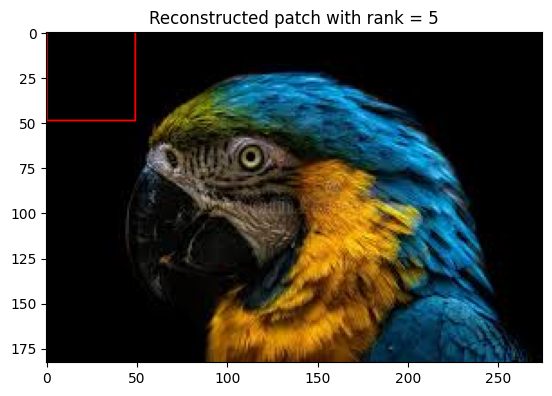

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0030477569..1.0].


Channel 0: Converged in 541 epochs.
Channel 1: Converged in 207 epochs.
Channel 2: Converged in 178 epochs.
Norm -  tensor(0.0462)


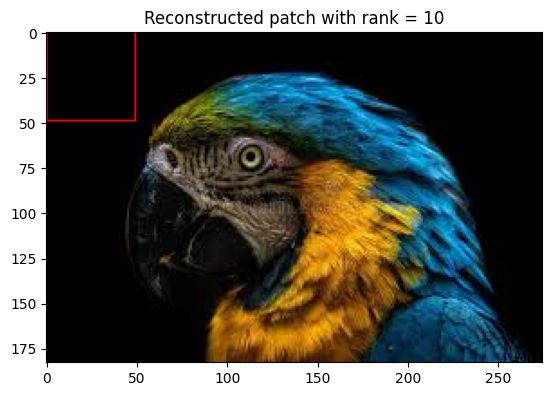

Channel 0: Converged in 226 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.004166498..1.0].


Channel 1: Converged in 1024 epochs.
Channel 2: Converged in 242 epochs.
Norm -  tensor(0.0626)


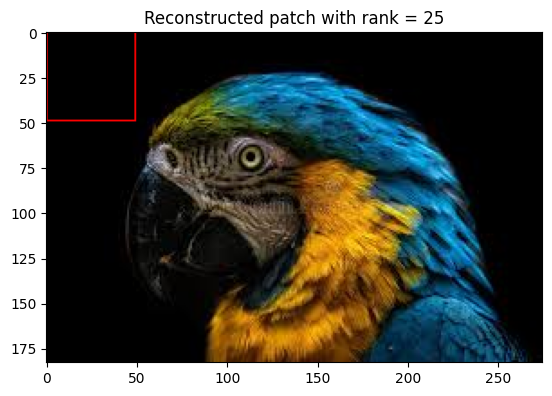

Channel 0: Converged in 1715 epochs.
Channel 1: Converged in 623 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014884205..1.0].


Channel 2: Converged in 273 epochs.
Norm -  tensor(0.2119)


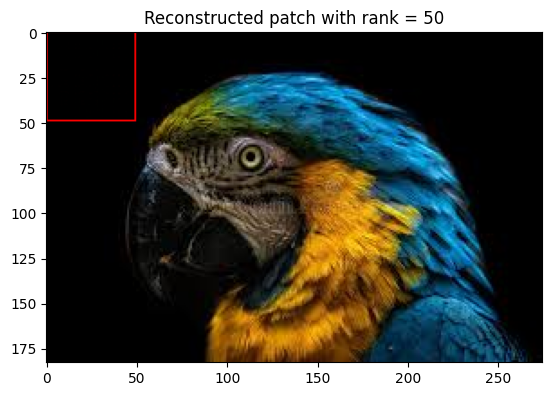

In [163]:
# Patch with single colour
img = torchvision.io.read_image("bird.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Plotting original image with red boundary
block_size = 50; top = 0; left = 0
red = [1.0, 0.0, 0.0]
imgCopy = img.permute(1, 2, 0).numpy().copy()
imgCopy[top, left:left+block_size] = red
imgCopy[top+block_size-1, left:left+block_size] = red
imgCopy[top:top+block_size, left] = red
imgCopy[top:top+block_size, left+block_size-1] = red
plt.title("Original Image with block")
plt.imshow(imgCopy)
plt.show()

# get the block 
block = img[:, top:top+block_size, left:left+block_size]
for k in [5, 10, 25, 50]:
    W, H = factorize_gd(block, k)
    reconstructed_img = img.clone() 
    reconstructed_img[:, top:top+block_size, left:left+block_size] = W@H
    print("Norm - ", torch.norm(block - W@H))
    imgCopy = reconstructed_img.permute(1, 2, 0).numpy().copy()
    # setting boundary as red
    imgCopy[top, left:left+block_size] = red
    imgCopy[top+block_size-1, left:left+block_size] = red
    imgCopy[top:top+block_size, left] = red
    imgCopy[top:top+block_size, left+block_size-1] = red
    # Display the result
    plt.title(f"Reconstructed patch with rank = {k}")
    plt.imshow(imgCopy)
    plt.axis('on') # Hides the axes for a cleaner look
    plt.show()


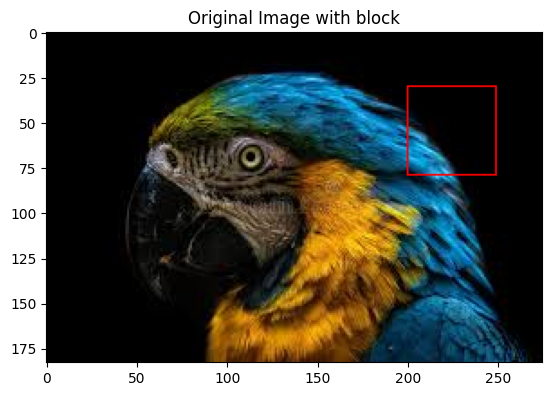

Channel 0: Converged in 300 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09231196..1.0].


Channel 1: Converged in 360 epochs.
Channel 2: Converged in 232 epochs.
Norm -  tensor(2.5736)


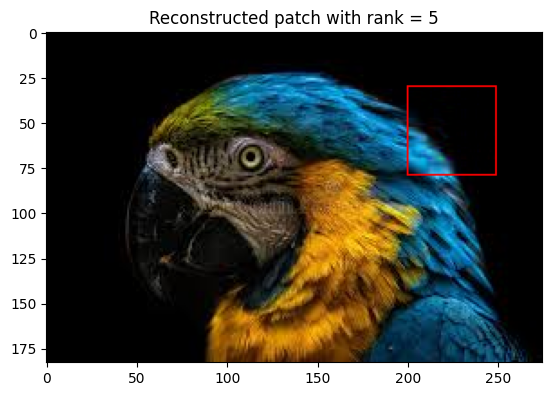

Channel 0: Converged in 491 epochs.
Channel 1: Converged in 506 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.056765545..1.0042285].


Channel 2: Converged in 605 epochs.
Norm -  tensor(1.0113)


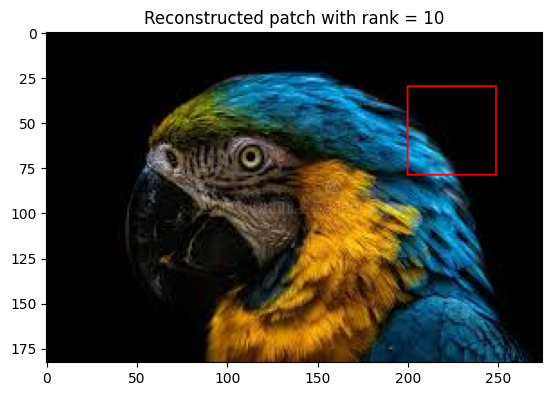

Channel 0: Converged in 923 epochs.
Channel 1: Converged in 680 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00971068..1.007336].


Channel 2: Converged in 637 epochs.
Norm -  tensor(0.1794)


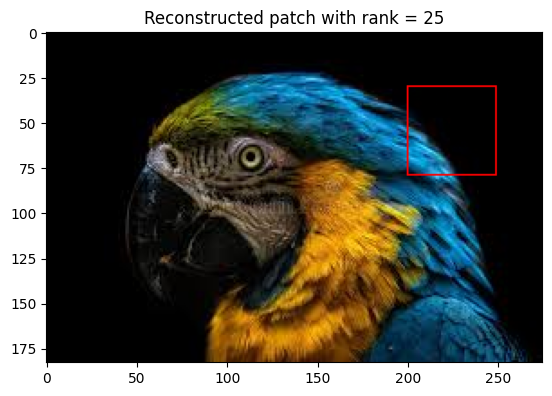

Channel 0: Converged in 479 epochs.
Channel 1: Converged in 451 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008801208..1.0].


Channel 2: Converged in 481 epochs.
Norm -  tensor(0.1540)


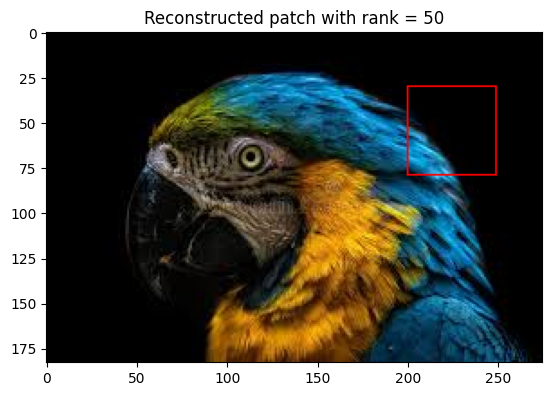

In [166]:
# Patch with single colour
img = torchvision.io.read_image("bird.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Plotting original image with red boundary
block_size = 50; top = 30; left = 200
red = [1.0, 0.0, 0.0]
imgCopy = img.permute(1, 2, 0).numpy().copy()
imgCopy[top, left:left+block_size] = red
imgCopy[top+block_size-1, left:left+block_size] = red
imgCopy[top:top+block_size, left] = red
imgCopy[top:top+block_size, left+block_size-1] = red
plt.title("Original Image with block")
plt.imshow(imgCopy)
plt.show()

# get the block 
block = img[:, top:top+block_size, left:left+block_size]
for k in [5, 10, 25, 50]:
    W, H = factorize_gd(block, k)
    reconstructed_img = img.clone() 
    reconstructed_img[:, top:top+block_size, left:left+block_size] = W@H
    print("Norm - ", torch.norm(block - W@H))
    imgCopy = reconstructed_img.permute(1, 2, 0).numpy().copy()
    # setting boundary as red
    imgCopy[top, left:left+block_size] = red
    imgCopy[top+block_size-1, left:left+block_size] = red
    imgCopy[top:top+block_size, left] = red
    imgCopy[top:top+block_size, left+block_size-1] = red
    # Display the result
    plt.title(f"Reconstructed patch with rank = {k}")
    plt.imshow(imgCopy)
    plt.axis('on') # Hides the axes for a cleaner look
    plt.show()


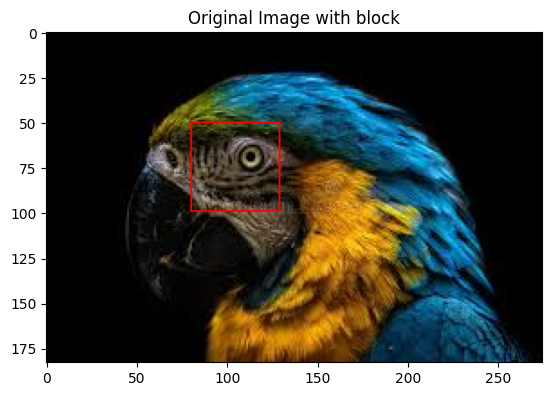

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0747157..1.0].


Channel 0: Converged in 252 epochs.
Channel 1: Converged in 264 epochs.
Channel 2: Converged in 237 epochs.
Norm -  tensor(6.7723)


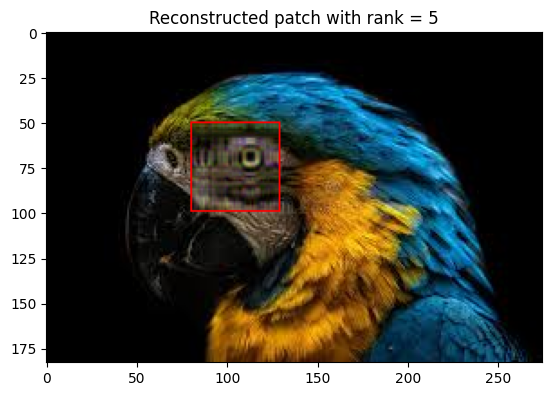

Channel 0: Converged in 333 epochs.
Channel 1: Converged in 326 epochs.
Channel 2: Converged in 337 epochs.
Norm -  tensor(4.8230)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14560819..1.0].


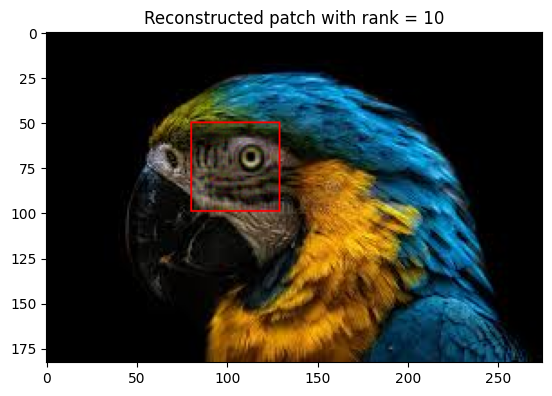

Channel 0: Converged in 560 epochs.
Channel 1: Converged in 563 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05354301..1.0].


Channel 2: Converged in 546 epochs.
Norm -  tensor(1.7685)


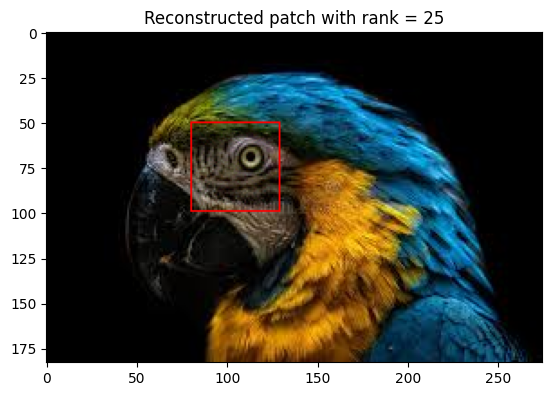

Channel 0: Converged in 536 epochs.
Channel 1: Converged in 647 epochs.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0063502253..1.0].


Channel 2: Converged in 604 epochs.
Norm -  tensor(0.1879)


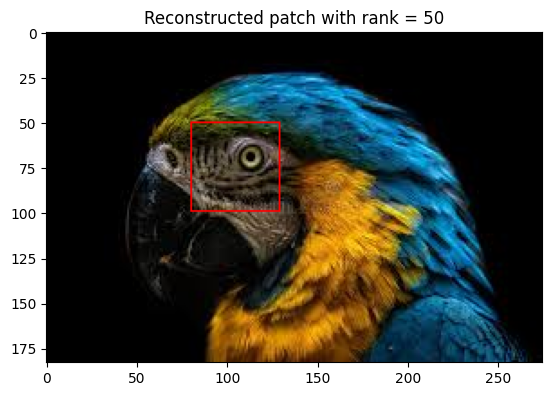

In [173]:
# Patch with single colour
img = torchvision.io.read_image("bird.png").to(torch.float32)/255  # shape: (3, n, m) # Normalized to 0 - 1

# Plotting original image with red boundary
block_size = 50; top = 50; left = 80
red = [1.0, 0.0, 0.0]
imgCopy = img.permute(1, 2, 0).numpy().copy()
imgCopy[top, left:left+block_size] = red
imgCopy[top+block_size-1, left:left+block_size] = red
imgCopy[top:top+block_size, left] = red
imgCopy[top:top+block_size, left+block_size-1] = red
plt.title("Original Image with block")
plt.imshow(imgCopy)
plt.show()

# get the block 
block = img[:, top:top+block_size, left:left+block_size]
for k in [5, 10, 25, 50]:
    W, H = factorize_gd(block, k)
    reconstructed_img = img.clone() 
    reconstructed_img[:, top:top+block_size, left:left+block_size] = W@H
    print("Norm - ", torch.norm(block - W@H))
    imgCopy = reconstructed_img.permute(1, 2, 0).numpy().copy()
    # setting boundary as red
    imgCopy[top, left:left+block_size] = red
    imgCopy[top+block_size-1, left:left+block_size] = red
    imgCopy[top:top+block_size, left] = red
    imgCopy[top:top+block_size, left+block_size-1] = red
    # Display the result
    plt.title(f"Reconstructed patch with rank = {k}")
    plt.imshow(imgCopy)
    plt.axis('on') # Hides the axes for a cleaner look
    plt.show()


Observation - 
The effectiveness of low-rank matrix factorization for image compression is highly dependent on the informational complexity of the image patch. For patches with low intrinsic rank, such as those with only one or two colors, a low-rank approximation is sufficient to capture the essential information, resulting in minimal reconstruction loss and high visual fidelity where increasing the rank yields negligible improvement. Conversely, for complex patches with high contrast and multiple colors, a low-rank approximation results in a significant loss of information, which is evident as a high reconstruction error and visible artifacts like blurring. In these cases, increasing the rank systematically reduces the reconstruction loss and markedly improves the visual quality by allowing the model to capture finer details.